<a href="https://colab.research.google.com/github/Akash-9794/numpy-100-challenges/blob/main/GSOC2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Install all required packages
!pip install astropy pytransit scikit-learn torch torchvision matplotlib numpy scipy -q
!pip install pytorch-msssim -q

print("All packages installed successfully")

All packages installed successfully


In [16]:
# Access ALMA dataset via Drive shortcut
from google.colab import drive
import os, glob

drive.mount('/content/drive')

# Path after adding shortcut to My Drive
DATASET_DIR = "/content/drive/MyDrive/1VkS3RHkAjiKjJ6DnZmEKZ_nUv4w6pz7P"

# Search recursively for all .fits files
fits_files = glob.glob(os.path.join(DATASET_DIR, "**/*.fits"), recursive=True)
fits_files += glob.glob(os.path.join(DATASET_DIR, "*.fits"))
fits_files = list(set(fits_files))

if len(fits_files) == 0:
    # Try searching all of MyDrive
    print("Searching all of MyDrive for .fits files...")
    fits_files = glob.glob("/content/drive/MyDrive/**/*.fits", recursive=True)

print(f"Found {len(fits_files)} .fits files")
print("Samples:", fits_files[:3])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching all of MyDrive for .fits files...
Found 150 .fits files
Samples: ['/content/drive/MyDrive/continuum_data_subset/planet0_00226_1250.fits', '/content/drive/MyDrive/continuum_data_subset/planet100_00580_1250.fits', '/content/drive/MyDrive/continuum_data_subset/planet10_00710_1250.fits']


Total .fits files: 150
Loading images...
Loaded: 150 images, shape per image: (600, 600)


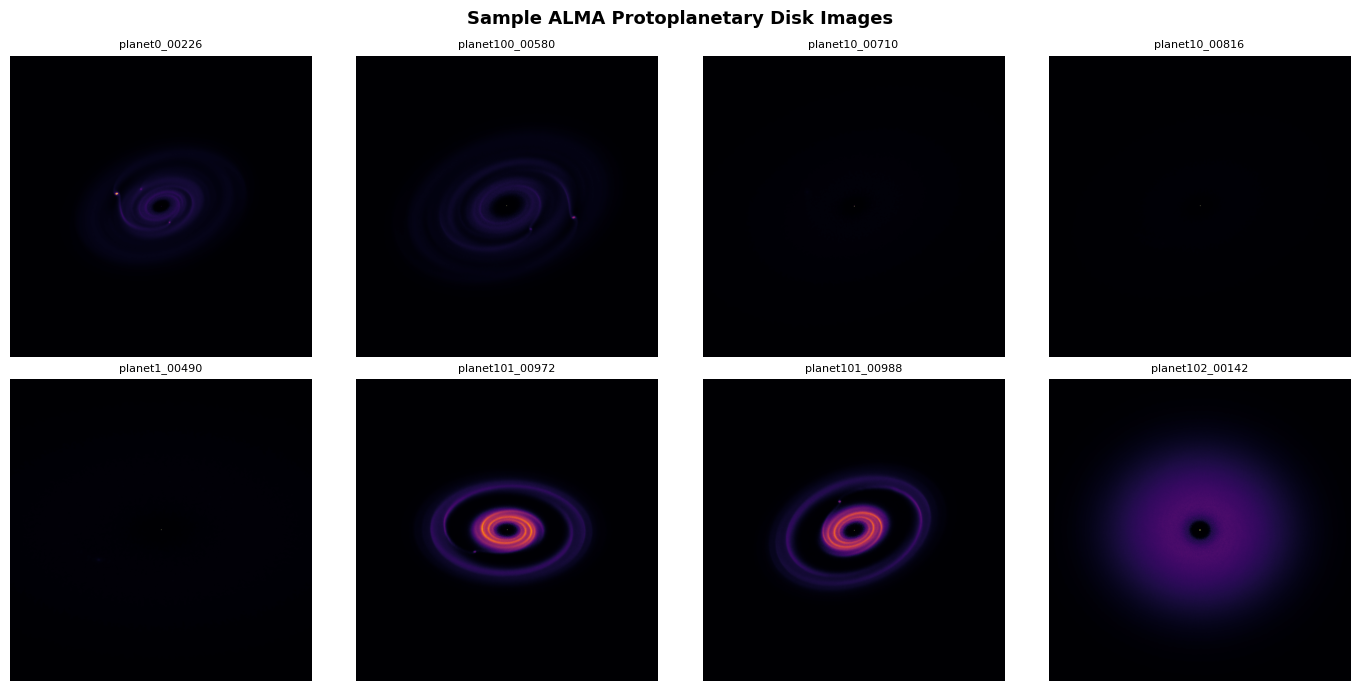

Cell 3 done!


In [17]:
# Load and preprocess .fits images (fixed for shape 4,1,1,600,600)
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os

DATASET_DIR = "/content/drive/MyDrive/continuum_data_subset"

fits_files = [
    os.path.join(DATASET_DIR, f)
    for f in os.listdir(DATASET_DIR)
    if f.endswith('.fits')
]
print(f"Total .fits files: {len(fits_files)}")

def load_fits_image(filepath):
    """Load and normalize a single 600x600 image from the .fits cube."""
    with fits.open(filepath) as hdul:
        data = hdul[0].data
    # Extract index 0 along first axis, then squeeze all size-1 dims
    img = data[0].squeeze()
    img = np.nan_to_num(img, nan=0.0)
    if img.max() > img.min():
        img = (img - img.min()) / (img.max() - img.min())
    return img.astype(np.float32)

# Load all images
print("Loading images...")
images, valid_files = [], []

for f in fits_files:
    try:
        img = load_fits_image(f)
        assert img.shape == (600, 600), f"Unexpected shape: {img.shape}"
        images.append(img)
        valid_files.append(f)
    except Exception as e:
        print(f"Skipped {os.path.basename(f)}: {e}")

images = np.array(images)
print(f"Loaded: {len(images)} images, shape per image: {images[0].shape}")

# Visualize 8 sample disks
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='inferno', origin='lower')
    name = os.path.basename(valid_files[i]).replace('_1250.fits', '')
    ax.set_title(name, fontsize=8)
    ax.axis('off')
plt.suptitle("Sample ALMA Protoplanetary Disk Images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_disks.png", dpi=150, bbox_inches='tight')
plt.show()
print("Cell 3 done!")

In [18]:
# Extract deep features using pretrained ResNet18
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained ResNet18, remove final classification layer
resnet = models.resnet18(weights='IMAGENET1K_V1')
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device).eval()

def extract_features(images_np):
    """Convert grayscale images to 3-channel tensors and extract CNN features."""
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    tensors = torch.stack([
        transform((img * 255).astype(np.uint8))
        for img in images_np
    ])

    dataset = TensorDataset(tensors)
    loader = DataLoader(dataset, batch_size=16, shuffle=False)

    features = []
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            feat = feature_extractor(batch).squeeze(-1).squeeze(-1)
            features.append(feat.cpu().numpy())

    return np.concatenate(features, axis=0)

print("Extracting features — please wait...")
features = extract_features(images)
print(f"Done! Feature matrix shape: {features.shape}")

Using device: cpu
Extracting features — please wait...
Done! Feature matrix shape: (150, 512)


Variance explained by 50 PCs: 95.1%


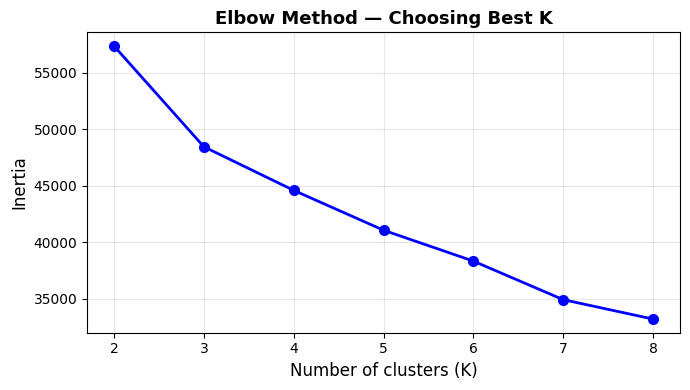


Cluster distribution:
  Cluster 0: 26 disks
  Cluster 1: 40 disks
  Cluster 2: 45 disks
  Cluster 3: 39 disks


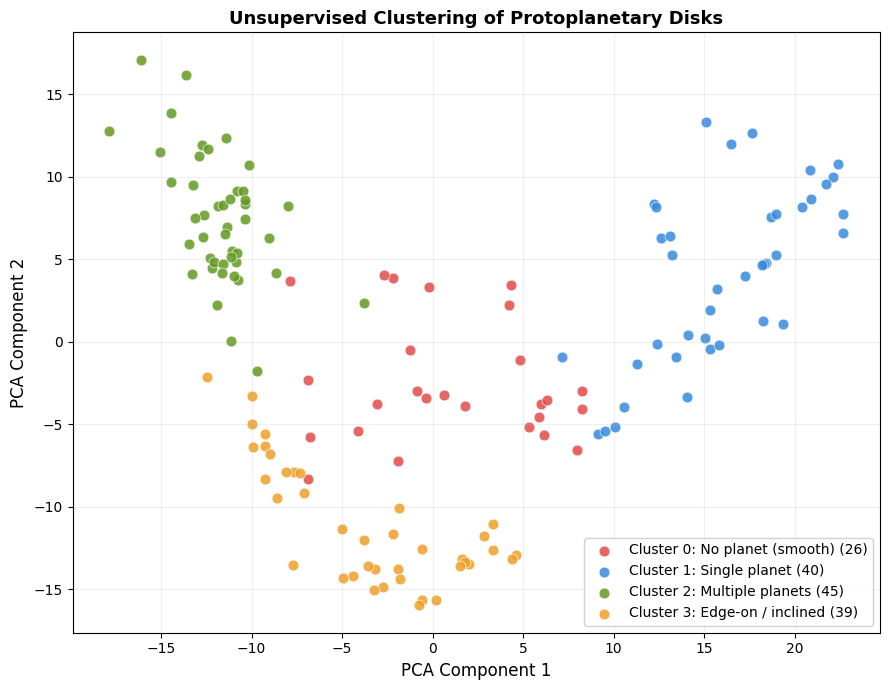

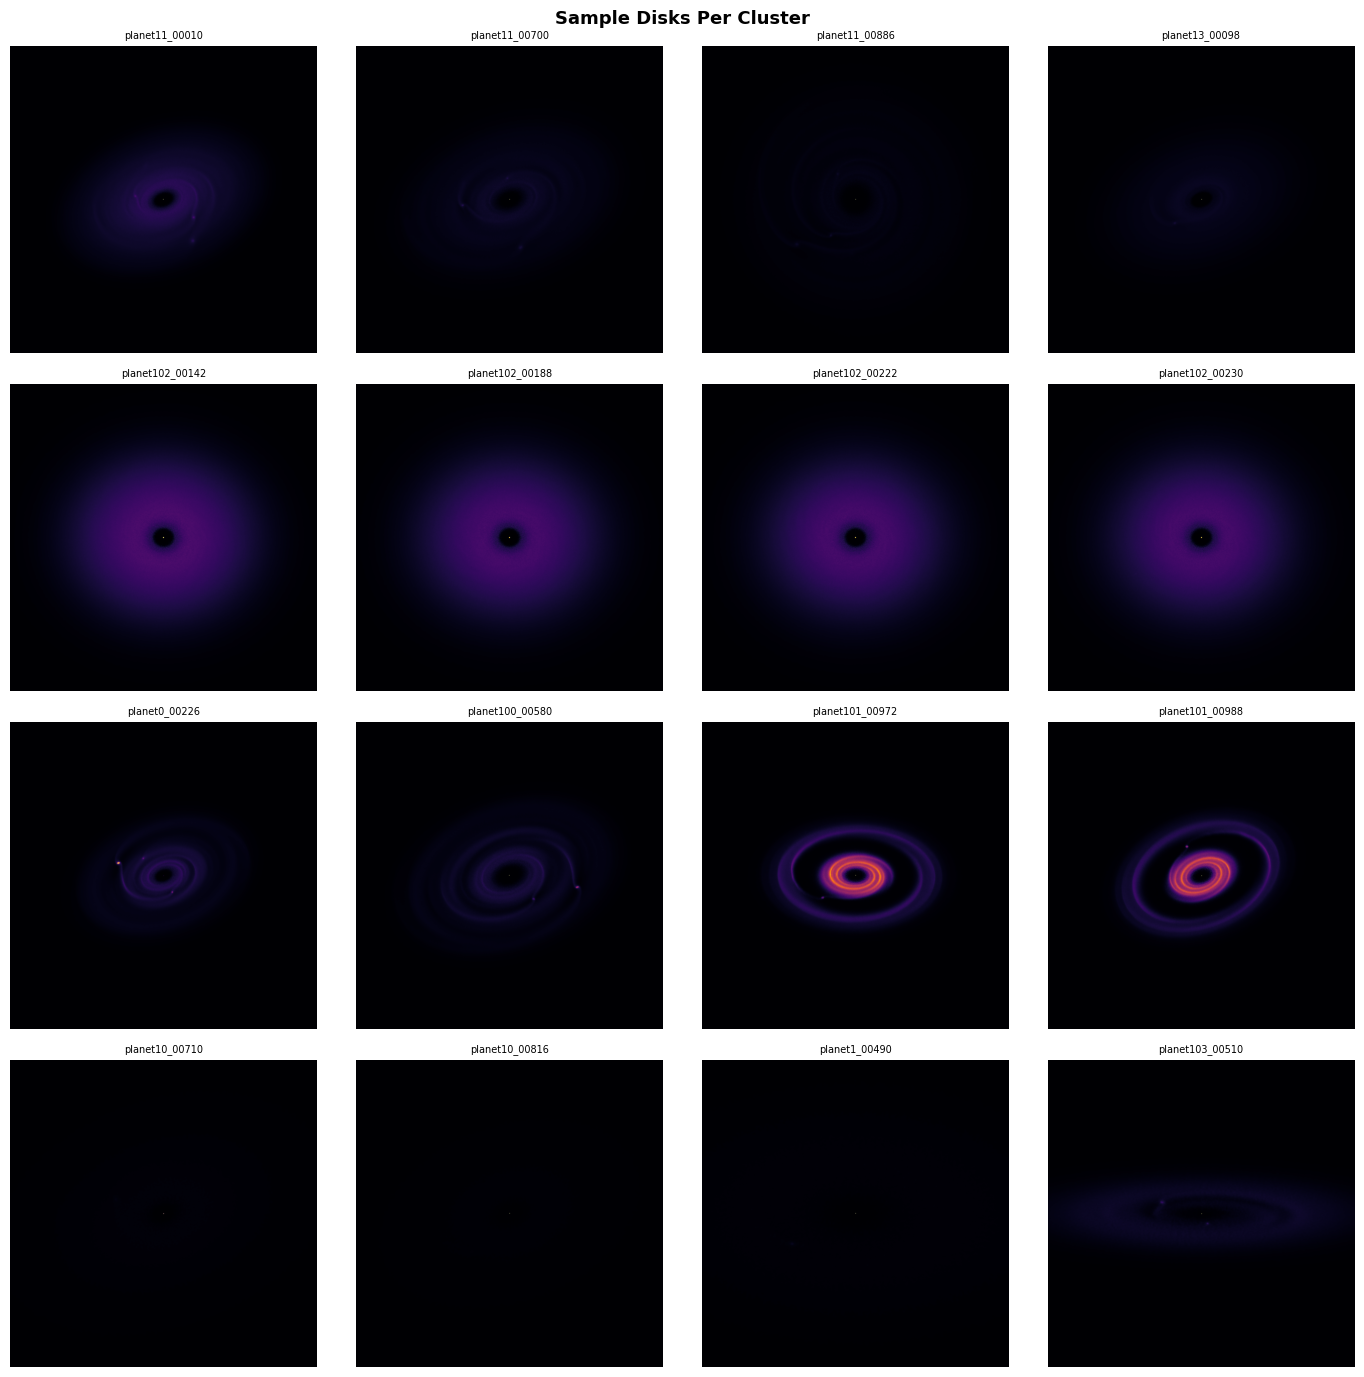


Task 1 COMPLETE!
Saved: kmeans_model.pkl, elbow_plot.png, cluster_scatter.png, cluster_samples.png


In [19]:
# PCA + K-Means clustering + visualization
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import os

# ──  Normalize features ──
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# ── Step 2: PCA reduction ──
pca_50 = PCA(n_components=50, random_state=42)
features_50d = pca_50.fit_transform(features_scaled)

pca_2d = PCA(n_components=2, random_state=42)
features_2d = pca_2d.fit_transform(features_50d)

print(f"Variance explained by 50 PCs: {pca_50.explained_variance_ratio_.sum()*100:.1f}%")

# ──  Elbow method to find best K ──
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_50d)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel("Number of clusters (K)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.title("Elbow Method — Choosing Best K", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Fit K-Means with K=4 ──
# (adjust this number based on the elbow plot)
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_50d)

print(f"\nCluster distribution:")
for i in range(N_CLUSTERS):
    count = (cluster_labels == i).sum()
    print(f"  Cluster {i}: {count} disks")

# ── Scatter plot of clusters ──
colors = ['#E24B4A', '#378ADD', '#639922', '#EF9F27']
cluster_names = [
    'No planet (smooth)',
    'Single planet',
    'Multiple planets',
    'Edge-on / inclined'
]

fig, ax = plt.subplots(figsize=(9, 7))
for i in range(N_CLUSTERS):
    mask = cluster_labels == i
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
               c=colors[i],
               label=f"Cluster {i}: {cluster_names[i]} ({mask.sum()})",
               s=60, alpha=0.85, edgecolors='white', linewidths=0.5)
ax.set_xlabel("PCA Component 1", fontsize=12)
ax.set_ylabel("PCA Component 2", fontsize=12)
ax.set_title("Unsupervised Clustering of Protoplanetary Disks",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Show 4 sample images per cluster ──
fig, axes = plt.subplots(N_CLUSTERS, 4, figsize=(14, N_CLUSTERS * 3.5))
for cluster_id in range(N_CLUSTERS):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    samples = cluster_indices[:4]
    for j, idx in enumerate(samples):
        axes[cluster_id, j].imshow(images[idx], cmap='inferno', origin='lower')
        axes[cluster_id, j].axis('off')
        name = os.path.basename(valid_files[idx]).replace('_1250.fits', '')
        axes[cluster_id, j].set_title(name, fontsize=7)
    axes[cluster_id, 0].set_ylabel(
        f"Cluster {cluster_id}\n{cluster_names[cluster_id]}",
        fontsize=9, labelpad=8
    )
plt.suptitle("Sample Disks Per Cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cluster_samples.png", dpi=150, bbox_inches='tight')
plt.show()

# ──  Save Task 1 model ──
import pickle
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump({
        "kmeans": kmeans,
        "pca_50": pca_50,
        "pca_2d": pca_2d,
        "scaler": scaler,
        "cluster_names": cluster_names
    }, f)

print("\nTask 1 COMPLETE!")
print("Saved: kmeans_model.pkl, elbow_plot.png, cluster_scatter.png, cluster_samples.png")

# TASK 2

Simulating light curves...
Dataset ready!
  Total curves : 2000
  Planet       : 1000
  No planet    : 1000
  Curve shape  : (200,)


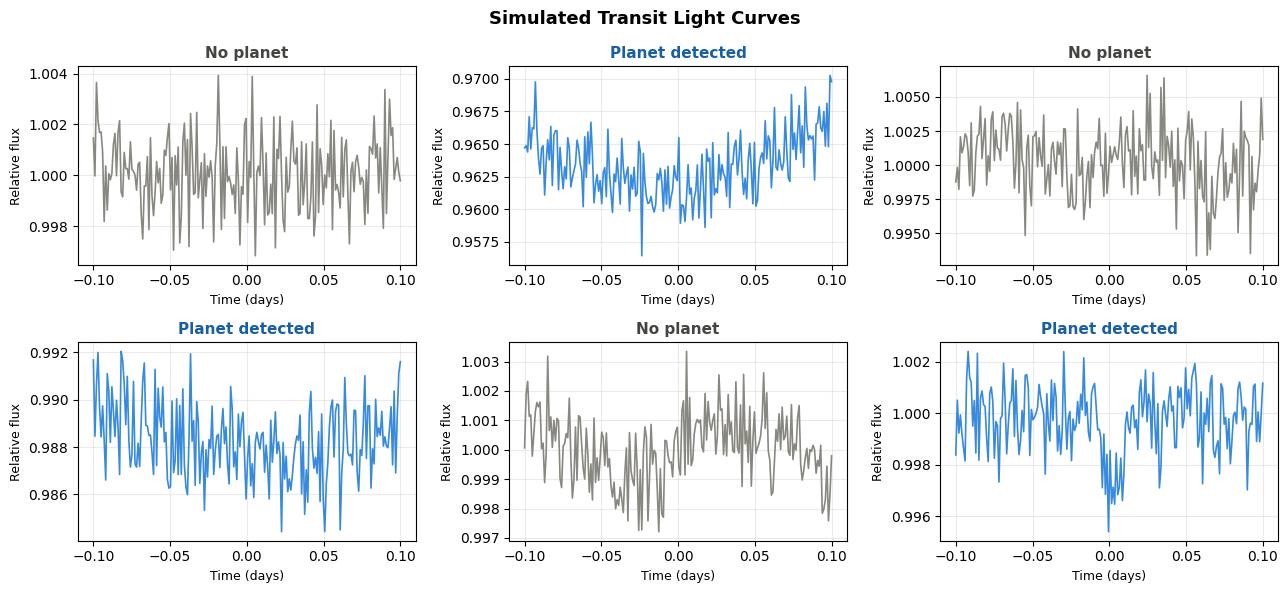

 done!


In [20]:
# Simulate transit light curves using PyTransit
import numpy as np
import matplotlib.pyplot as plt
from pytransit import QuadraticModel

np.random.seed(42)

N_PLANET    = 1000  # curves WITH a planet
N_NO_PLANET = 1000  # curves WITHOUT a planet
N_POINTS    = 200   # time steps per curve

# Time array centered on transit
time = np.linspace(-0.1, 0.1, N_POINTS)

tm = QuadraticModel()
tm.set_data(time)

def simulate_planet_curve():
    """Simulate a realistic transit light curve with a planet."""
    k  = np.random.uniform(0.05, 0.20)   # planet/star radius ratio
    t0 = np.random.uniform(-0.01, 0.01)  # mid-transit time offset
    p  = np.random.uniform(1.0, 10.0)    # orbital period (days)
    a  = np.random.uniform(5.0, 15.0)    # semi-major axis
    i  = np.random.uniform(85.0, 90.0)   # inclination (degrees)
    u  = [np.random.uniform(0.2, 0.5),
          np.random.uniform(0.1, 0.3)]   # limb darkening coefficients
    flux = tm.evaluate(k=k, ldc=u, t0=t0, p=p, a=a, i=np.deg2rad(i))
    noise = np.random.normal(0, np.random.uniform(0.0005, 0.002), N_POINTS)
    return (flux + noise).astype(np.float32)

def simulate_no_planet_curve():
    """Simulate a flat light curve with no planet — just noise."""
    baseline = np.ones(N_POINTS, dtype=np.float32)
    noise = np.random.normal(0, np.random.uniform(0.0005, 0.003), N_POINTS)
    # Occasionally add stellar variability (not a transit)
    if np.random.random() < 0.3:
        baseline += 0.001 * np.sin(
            2 * np.pi * time / np.random.uniform(0.05, 0.2)
        )
    return (baseline + noise).astype(np.float32)

print("Simulating light curves...")
planet_curves    = np.array([simulate_planet_curve()    for _ in range(N_PLANET)])
no_planet_curves = np.array([simulate_no_planet_curve() for _ in range(N_NO_PLANET)])

X = np.concatenate([planet_curves, no_planet_curves], axis=0)
y = np.array([1]*N_PLANET + [0]*N_NO_PLANET, dtype=np.float32)

# Shuffle
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

print(f"Dataset ready!")
print(f"  Total curves : {len(X)}")
print(f"  Planet       : {int(y.sum())}")
print(f"  No planet    : {int((1-y).sum())}")
print(f"  Curve shape  : {X[0].shape}")

# Visualize 6 example curves
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    label = int(y[i])
    color = '#378ADD' if label == 1 else '#888780'
    ax.plot(time, X[i], color=color, linewidth=1.2)
    ax.set_title("Planet detected" if label else "No planet",
                 fontsize=11,
                 color='#185FA5' if label else '#444441',
                 fontweight='bold')
    ax.set_xlabel("Time (days)", fontsize=9)
    ax.set_ylabel("Relative flux", fontsize=9)
    ax.grid(True, alpha=0.25)
plt.suptitle("Simulated Transit Light Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("light_curves_sample.png", dpi=150, bbox_inches='tight')
plt.show()
print(" done!")

In [21]:
# Build 1D-CNN transit classifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class TransitClassifier(nn.Module):
    def __init__(self, input_len=200):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
        )
        conv_out = input_len // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * conv_out, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 64),             nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),               nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        return self.classifier(self.conv_block(x)).squeeze(1)

model = TransitClassifier(input_len=N_POINTS).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model built! Total parameters: {total_params:,}")

# ── Train / Val / Test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42)

def make_loader(X, y, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("done!")

Using device: cpu
Model built! Total parameters: 871,681
Train: 1360 | Val: 240 | Test: 400
done!


Training started...

Epoch   5 | Train Loss: 0.0783 | Val Loss: 2.5573 | Val Acc: 0.7708
Epoch  10 | Train Loss: 0.0632 | Val Loss: 0.1512 | Val Acc: 0.9542
Epoch  15 | Train Loss: 0.0688 | Val Loss: 0.0324 | Val Acc: 0.9958

Early stopping triggered at epoch 16


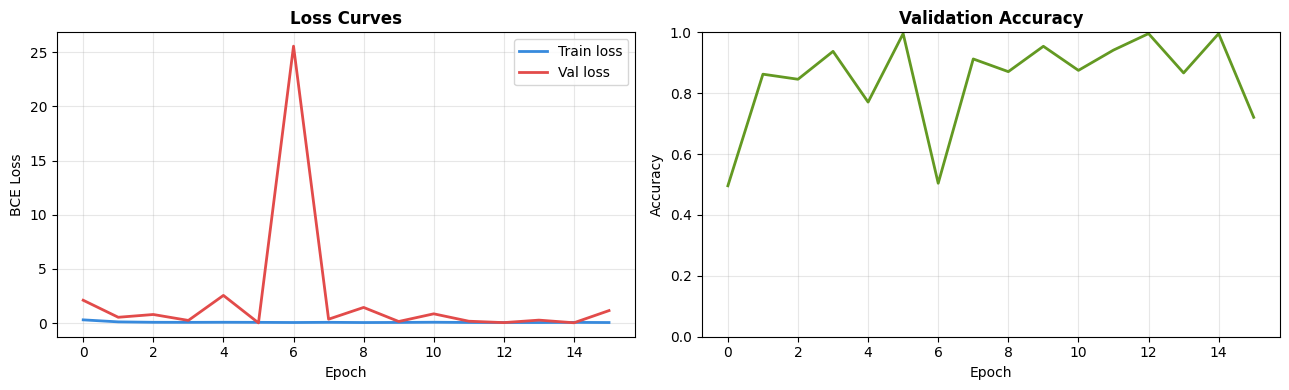


Best val loss: 0.0217
done!


In [22]:
# Train the transit classifier
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5)

EPOCHS = 40
EARLY_STOP_PATIENCE = 10
best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses, val_accs = [], [], []

print("Training started...\n")
for epoch in range(EPOCHS):

    # ── Training ──
    model.train()
    t_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    # ── Validation ──
    model.eval()
    v_loss, correct = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            v_loss  += criterion(preds, yb).item()
            correct += ((preds > 0.5).float() == yb).sum().item()

    t_loss /= len(train_loader)
    v_loss /= len(val_loader)
    v_acc   = correct / len(X_val)
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    val_accs.append(v_acc)
    scheduler.step(v_loss)

    # Early stopping
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), "transit_classifier_best.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {t_loss:.4f} | "
              f"Val Loss: {v_loss:.4f} | "
              f"Val Acc: {v_acc:.4f}")

# ── Plot training curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(train_losses, label='Train loss', color='#378ADD', linewidth=2)
ax1.plot(val_losses,   label='Val loss',   color='#E24B4A', linewidth=2)
ax1.set_title("Loss Curves", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(val_accs, color='#639922', linewidth=2)
ax2.set_title("Validation Accuracy", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBest val loss: {best_val_loss:.4f}")
print("done!")


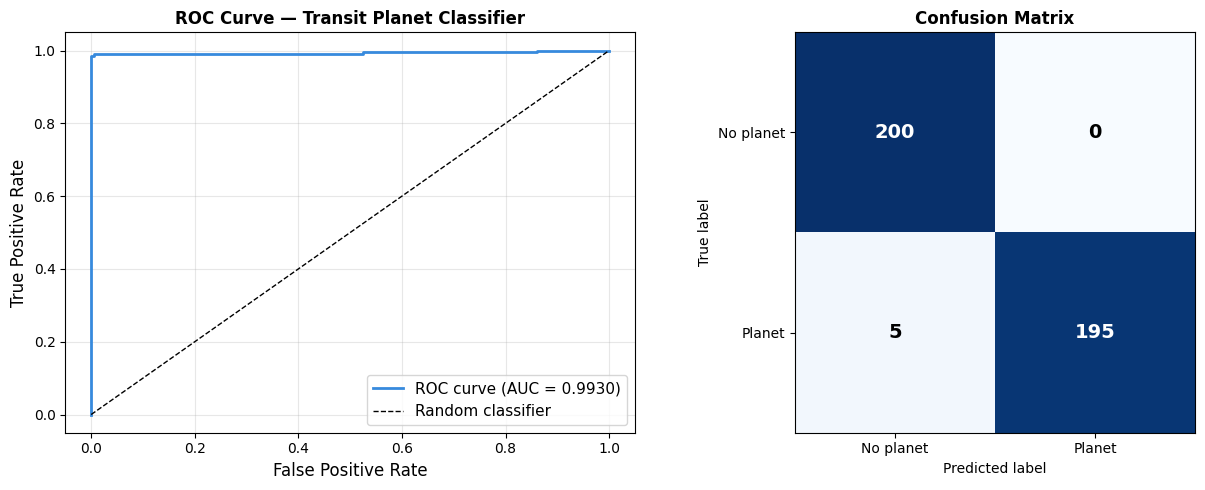

Test AUC Score : 0.9930

Classification Report:
              precision    recall  f1-score   support

   No planet       0.98      1.00      0.99       200
      Planet       1.00      0.97      0.99       200

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400

done!


In [14]:
# Full evaluation — ROC curve, AUC, confusion matrix
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                              classification_report)
import itertools

# Load best saved model
model.load_state_dict(torch.load("transit_classifier_best.pt",
                                  map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(model(xb.to(device)).cpu().numpy())
        all_labels.append(yb.numpy())

all_preds    = np.concatenate(all_preds)
all_labels   = np.concatenate(all_labels)
binary_preds = (all_preds > 0.5).astype(int)

# ROC + AUC
fpr, tpr, _ = roc_curve(all_labels, all_preds)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fpr, tpr, color='#378ADD', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
ax1.set_xlabel("False Positive Rate", fontsize=12)
ax1.set_ylabel("True Positive Rate", fontsize=12)
ax1.set_title("ROC Curve — Transit Planet Classifier",
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(all_labels, binary_preds)
ax2.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax2.set_title("Confusion Matrix", fontsize=12, fontweight='bold')
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(['No planet', 'Planet'])
ax2.set_yticklabels(['No planet', 'Planet'])
ax2.set_ylabel("True label")
ax2.set_xlabel("Predicted label")
for i, j in itertools.product(range(2), range(2)):
    ax2.text(j, i, str(cm[i,j]), ha='center', va='center',
             color='white' if cm[i,j] > cm.max()/2 else 'black',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("roc_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Test AUC Score : {roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(all_labels, binary_preds,
                            target_names=['No planet', 'Planet']))
print("done!")

In [24]:
# Inference pipelines + save all to Google Drive
import pickle, shutil, os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)
SAVE_DIR = '/content/drive/MyDrive/ML4Sci_EXXA3_Submission'
os.makedirs(SAVE_DIR, exist_ok=True)

# ──   inference function ──
def predict_disk_cluster(fits_filepath):
    """Given a .fits file path, return its cluster label and name."""
    img  = load_fits_image(fits_filepath)
    feat = extract_features(np.array([img]))
    feat_scaled = scaler.transform(feat)
    feat_50d    = pca_50.transform(feat_scaled)
    label = kmeans.predict(feat_50d)[0]
    print(f"Cluster {label}: {cluster_names[label]}")
    return label

# ──   inference function ──
def predict_transit(light_curve_array):
    """Given a 1D numpy array of length 200, return planet probability."""
    model.load_state_dict(torch.load("transit_classifier_best.pt",
                                     map_location=device))
    model.eval()
    t = torch.tensor(light_curve_array,
                     dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = model(t).item()
    result = "PLANET DETECTED" if prob > 0.5 else "No planet"
    print(f"Planet probability: {prob:.4f} → {result}")
    return prob

# ── Test both  ──
print("Testing Task 1 inference...")
predict_disk_cluster(valid_files[0])

print("\nTesting Task 2 inference...")
test_curve = simulate_planet_curve()
predict_transit(test_curve)

# ── Save models ──
torch.save(model.state_dict(),
           f"{SAVE_DIR}/transit_classifier_best.pt")

with open(f"{SAVE_DIR}/kmeans_pipeline.pkl", "wb") as f:
    pickle.dump({
        "kmeans"       : kmeans,
        "pca_50"       : pca_50,
        "pca_2d"       : pca_2d,
        "scaler"       : scaler,
        "cluster_names": cluster_names
    }, f)

# ── Save all plots ──
plots = [
    "sample_disks.png",
    "elbow_plot.png",
    "cluster_scatter.png",
    "cluster_samples.png",
    "light_curves_sample.png",
    "training_curves.png",
    "roc_confusion.png"
]

for p in plots:
    if os.path.exists(p):
        shutil.copy(p, SAVE_DIR)
        print(f"Saved: {p}")

print(f"\nAll files saved to: {SAVE_DIR}")
print("\n========== SUBMISSION CHECKLIST ==========")
print("  [✓] Task 1 — Disk clustering + K-Means model")
print("  [✓] Task 2 — Transit classifier (AUC = 0.9930)")
print("  [✓] Task 1 inference function tested")
print("  [✓] Task 2 inference function tested")
print("  [✓] All 7 plots saved to Google Drive")
print("  [✓] Models saved to Google Drive")
print("==========================================")
print("\nCongratulations to you ! Evaluation test COMPLETE!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Testing Task 1 inference...
Cluster 2: Multiple planets

Testing Task 2 inference...
Planet probability: 1.0000 → PLANET DETECTED
Saved: sample_disks.png
Saved: elbow_plot.png
Saved: cluster_scatter.png
Saved: cluster_samples.png
Saved: light_curves_sample.png
Saved: training_curves.png
Saved: roc_confusion.png

All files saved to: /content/drive/MyDrive/ML4Sci_EXXA3_Submission

========== SUBMISSION CHECKLIST ==========
  [✓] Task 1 — Disk clustering + K-Means model
  [✓] Task 2 — Transit classifier (AUC = 0.9930)
  [✓] Task 1 inference function tested
  [✓] Task 2 inference function tested
  [✓] All 7 plots saved to Google Drive
  [✓] Models saved to Google Drive

Congratulations to you ! Evaluation test COMPLETE!
